# Práctica: Regresión Lineal — Predicción de Precios de Vivienda
### Dataset: California Housing (Scikit-Learn)

En esta práctica se cubre: obtención y preprocesamiento de datos, análisis de variables, separación entrenamiento/prueba, implementación del modelo, evaluación con métricas de regresión, y predicción con datos nuevos.

In [1]:
## Importamos las librerías necesarias para el análisis y el modelo de ML
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing # descarga y carga el dataset 
from sklearn.model_selection import train_test_split #divicion 
from sklearn.preprocessing import StandardScaler  # escaldo
from sklearn.linear_model import LinearRegression # importa el algoritmo 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score   # importa las metricas 

In [2]:
## Descargamos el dataset California Housing directamente desde Scikit-Learn
## Fuente: repositorio interno de sklearn.datasets
datos = fetch_california_housing(as_frame=True)
df = datos.frame

## Visualizamos las primeras filas para confirmar que se cargó correctamente
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
## Revisamos información general: tipos de datos y cantidad de registros
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [4]:
## Verificamos si existen valores nulos (parte del preprocesamiento)
## Este dataset viene limpio de fábrica, pero siempre se debe comprobar
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [5]:
## Revisamos estadísticas descriptivas para detectar posibles valores atípicos (outliers)
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## 2. Importancia de las variables

In [6]:
## Separamos las variables predictoras (X) de la variable objetivo (y)
## Variable objetivo: MedHouseVal (precio medio de la vivienda, en cientos de miles de USD)
## Variables predictoras: el resto de columnas (ingreso medio, antigüedad, habitaciones, etc.)
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

print("Variables predictoras:", list(X.columns))
print("Variable objetivo: MedHouseVal")

Variables predictoras: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Variable objetivo: MedHouseVal


In [7]:
## Calculamos la correlación de cada variable predictora con la variable objetivo
## Esto nos da una primera idea de qué variables son más relevantes
correlaciones = df.corr()['MedHouseVal'].drop('MedHouseVal').sort_values(ascending=False)
correlaciones

MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160
Name: MedHouseVal, dtype: float64

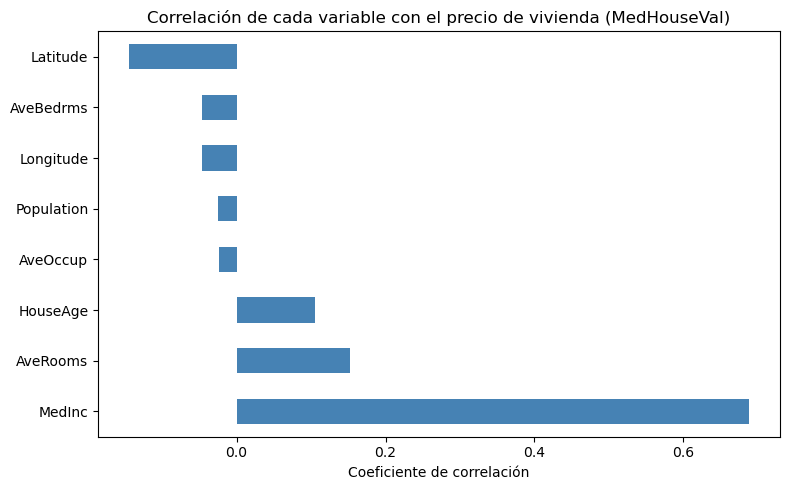

In [8]:
## Graficamos la correlación de cada variable con el precio de vivienda
## (una forma simple y válida de mostrar "importancia de variables" antes de entrenar)
plt.figure(figsize=(8,5))
correlaciones.plot(kind='barh', color='steelblue')
plt.title('Correlación de cada variable con el precio de vivienda (MedHouseVal)')
plt.xlabel('Coeficiente de correlación')
plt.tight_layout()
plt.show()

## 3. Separación de datos: entrenamiento y prueba

In [10]:
## Separamos los datos en conjunto de entrenamiento (80%) y prueba (20%)
## random_state=42 fija la semilla para que la división sea reproducible
## No se usa estratificación porque el target es continuo (la estratificación aplica a clases, no a valores numéricos)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Tamaño de entrenamiento:", X_train.shape)
print("Tamaño de prueba:", X_test.shape)

Tamaño de entrenamiento: (16512, 8)
Tamaño de prueba: (4128, 8)


In [11]:
## Escalado de variables: ajustamos el scaler SOLO con datos de entrenamiento
## y lo aplicamos (transform) tanto a entrenamiento como a prueba
## Esto evita fuga de información del conjunto de prueba hacia el entrenamiento
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform en train
X_test_scaled = scaler.transform(X_test)          # solo transform en test

## 4. Implementación del modelo

In [12]:
## Creamos y entrenamos el modelo de Regresión Lineal
## Librería: sklearn.linear_model.LinearRegression
## Parámetro relevante: fit_intercept=True (por defecto), permite que el modelo calcule el bias/intercepto
modelo = LinearRegression(fit_intercept=True)
modelo.fit(X_train_scaled, y_train)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


In [13]:
## Revisamos los coeficientes aprendidos (uno por cada variable predictora) y el intercepto
coeficientes = pd.DataFrame({
    'variable': X.columns,
    'coeficiente': modelo.coef_
}).sort_values('coeficiente', key=abs, ascending=False)

print("Intercepto (beta_0):", modelo.intercept_)
coeficientes

Intercepto (beta_0): 2.0719469373788777


,variable,coeficiente
6,Latitude,-0.896929
7,Longitude,-0.869842
0,MedInc,0.854383
3,AveBedrms,0.339259
2,AveRooms,-0.294410
1,HouseAge,0.122546
5,AveOccup,-0.040829
4,Population,-0.002308


In [14]:
## Generamos las predicciones sobre el conjunto de prueba
y_pred = modelo.predict(X_test_scaled)

## Mostramos las primeras predicciones comparadas contra el valor real
comparacion = pd.DataFrame({'Real': y_test.values[:10], 'Predicho': y_pred[:10]})
comparacion

,Real,Predicho
0,0.47700,0.719123
1,0.45800,1.764017
2,5.00001,2.709659
3,2.18600,2.838926
4,2.78000,2.604657
5,1.58700,2.011754
6,1.98200,2.645500
7,1.57500,2.168755
8,3.40000,2.740746
9,4.46600,3.915615


## 5. Evaluación del modelo

In [15]:
## Calculamos las métricas de evaluación adecuadas para un problema de REGRESIÓN
##  aquí el target es un valor numérico continuo, no una categoría/clase)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  (Error Absoluto Medio):     {mae:.3f}")
print(f"MSE  (Error Cuadrático Medio):   {mse:.3f}")
print(f"RMSE (Raíz del Error Cuadrático): {rmse:.3f}")
print(f"R²   (Coeficiente de determinación): {r2:.3f}")

MAE  (Error Absoluto Medio):     0.533
MSE  (Error Cuadrático Medio):   0.556
RMSE (Raíz del Error Cuadrático): 0.746
R²   (Coeficiente de determinación): 0.576


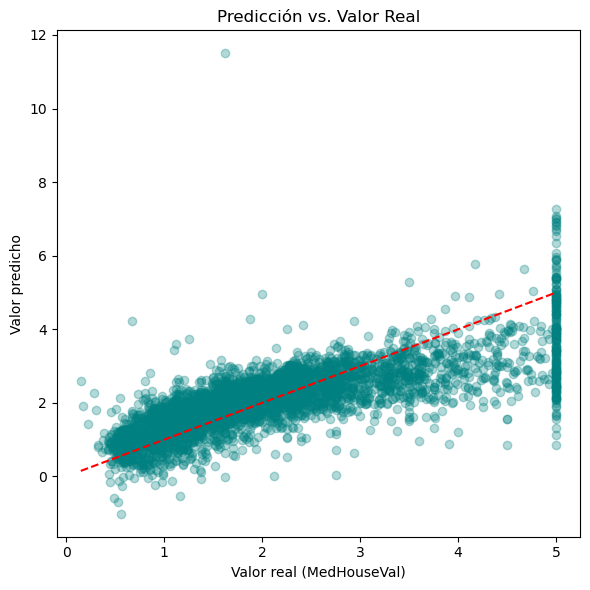

In [16]:
## Graficamos valores reales vs. predichos para visualizar el desempeño del modelo
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.3, color='teal')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # línea de referencia "predicción perfecta"
plt.xlabel('Valor real (MedHouseVal)')
plt.ylabel('Valor predicho')
plt.title('Predicción vs. Valor Real')
plt.tight_layout()
plt.show()

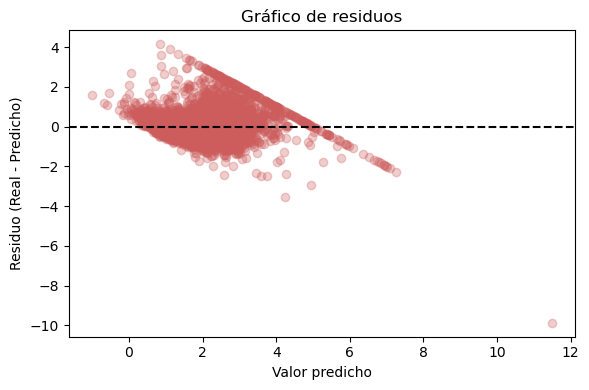

In [17]:
## Graficamos los residuos (errores) para verificar si el modelo lineal es adecuado
residuos = y_test - y_pred
plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuos, alpha=0.3, color='indianred')
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel('Valor predicho')
plt.ylabel('Residuo (Real - Predicho)')
plt.title('Gráfico de residuos')
plt.tight_layout()
plt.show()

In [18]:
## Probamos el modelo con un dato COMPLETAMENTE nuevo (inventado), simulando un caso real
## El formato de entrada debe tener EXACTAMENTE las mismas columnas y orden que X_train

nuevo_dato = pd.DataFrame({
    'MedInc': [5.5],       # ingreso medio de la zona (en decenas de miles de USD)
    'HouseAge': [15],      # antigüedad de la vivienda en años
    'AveRooms': [6.0],     # promedio de habitaciones por casa
    'AveBedrms': [1.1],    # promedio de dormitorios por casa
    'Population': [1200],  # población del bloque censal
    'AveOccup': [3.0],     # ocupación promedio por vivienda
    'Latitude': [34.05],   # ubicación (ej. cerca de Los Ángeles)
    'Longitude': [-118.25]
})

nuevo_dato

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,5.5,15,6.0,1.1,1200,3.0,34.05,-118.25


In [19]:
## IMPORTANTE: aplicamos el MISMO preprocesamiento usado en entrenamiento (mismo scaler, ya ajustado)
## Nunca se debe volver a hacer fit() aquí, solo transform()
nuevo_dato_scaled = scaler.transform(nuevo_dato)

## Generamos la predicción
prediccion_nueva = modelo.predict(nuevo_dato_scaled)

print(f"Precio medio de vivienda predicho: {prediccion_nueva[0]:.3f} (en cientos de miles de USD)")
print(f"Equivalente aproximado: ${prediccion_nueva[0]*100000:,.2f} USD")

Precio medio de vivienda predicho: 2.691 (en cientos de miles de USD)
Equivalente aproximado: $269,084.75 USD


## CONCLUCIONES 

La regresión lineal es un algoritmo fundamental del Machine Learning porque, con un modelo matemático simple, resuelve un problema clave: predecir un valor numérico a partir de datos históricos. Es útil porque es interpretable (cada coeficiente explica claramente el efecto de cada variable), rápido de entrenar, y sirve como punto de referencia antes de usar modelos más complejos